# 🔍 LLM Explorer — The 4GB VRAM Decision Guide
## How to Pick the Right AI Model for Your Machine

**What this notebook does:**
-  Fetches real model data from the HuggingFace API
-  Calculates true VRAM requirements across quantization levels
-  Filters models that actually run within your VRAM budget
-  Guides you to pick the right model for your use case

> 🎯 **Who this notebook is for:** Beginners and learners who want a guided, transparent decision process — not just a list.
> HuggingFace's own filter has far more models, but it won't calculate VRAM per quantization level, rank models by efficiency, or walk you through a decision framework. This notebook does all three.
> Think of it as a **teaching tool + decision assistant**, not a complete model directory.

---
> 📌 **Data source**: HuggingFace Official API · Inspired by [llm-explorer.com/list/?4GB](https://llm-explorer.com/list/?4GB)

**Attribution**
Notebook developed by SzuLun Huang <szuh@berkeley.edu>  
Under the guidance of Eric Van Dusen <ericvd@berkeley.edu>  
UC Berkeley, Data Science

---
## 🖥️ Step 0 — Check Your Own VRAM First

Before picking a model, you need to know how much GPU memory your machine has.

---

### 🪟 Windows
1. Press **`Ctrl + Shift + Esc`** to open Task Manager
2. Click the **"Performance"** tab
3. Click **"GPU"** on the left
4. Look for **"Dedicated GPU Memory"** — that's your VRAM

---

### 🍎 Mac (Apple Silicon — M1 / M2 / M3 / M4)
1. Click the **Apple menu** (top-left corner) → "About This Mac"
2. Look at **"Memory"** — this is your Unified Memory (shared between CPU and GPU)
3. **Rule of thumb**: You can safely give ~**half** to an LLM

> Example: 16 GB Mac → ~6–8 GB available for a model (leaving room for macOS + browser + other apps)

---

### 🐧 Linux
Open a terminal and run:
```bash
lspci | grep -i vga
nvidia-smi
```
Look for the **"Memory-Usage"** row — the total is your VRAM.

---

### ⚠️ The "Just Because You Have It Doesn't Mean You Should Use All of It" Rule
**A smarter approach:**

| Your Total Memory | Recommended Model Budget | Leave for System |
|-------------------|--------------------------|------------------|
| 4 GB              | ≤ 3 GB                   | ~1 GB            |
| 8 GB              | ≤ 5 GB                   | ~3 GB            |
| 16 GB             | ≤ 8 GB                   | ~8 GB            |
| 32 GB             | ≤ 20 GB                  | ~12 GB           |



---
##  Background — Why Does VRAM Matter?

VRAM (Video RAM) is the memory on your GPU. When you run an LLM, all the model weights need to fit inside it.

| Quantization | Bytes per Parameter | Quality | Notes |
|-------------|---------------------|---------|-------|
| FP32        | 4 bytes             | Best    | Rarely used for inference |
| FP16        | 2 bytes             | Excellent | Most common training format |
| Q8          | 1 byte              | Near-lossless | Great balance |
| Q4          | 0.5 bytes           | Good    | ~5–10% quality loss, runs anywhere |

**Formula**: `VRAM (GB) ≈ Parameters (B) × bytes_per_param × 1.10 (overhead)`

**4GB is the VRAM of entry-level GPUs** (RTX 3050, older MacBooks) — the lowest common denominator for running local LLMs.

## ⚙️ Step 0: Install & Import All Libraries

> **Why:** Every tool this notebook uses must be loaded before anything else can run.  
> **What:** Installs any missing packages, then imports all libraries — HuggingFace, pandas, matplotlib, widgets, and more.  
> **How:** Run this cell once. You only need to re-run it if you restart the kernel.

In [10]:
# ── Step 0: Install & Import ─────────────────────────────────
# Run this cell FIRST, once per session.
# Installs any missing packages, then loads all tools the notebook needs.

# ── 1. Install packages (skipped automatically if already installed) ──
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "huggingface-hub",  # fetch real model data from HuggingFace API
    "pandas",           # data manipulation (DataFrames, filtering, sorting)
    "numpy",            # numerical calculations (VRAM formulas)
    "matplotlib",       # charts and visualizations
    "seaborn",          # chart styling
    "ipywidgets",       # interactive sliders, dropdowns, buttons
    "pyyaml",           # read model card metadata (YAML format)
    "datasets",         # load Open LLM Leaderboard benchmark scores
])
from datasets import load_dataset

# ── 2. Silence noisy warnings ─────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── 3. HuggingFace — fetch model metadata & card info ────────
from huggingface_hub import list_models, model_info

# ── 4. Data & numerics ────────────────────────────────────────
import pandas as pd       # main data structure for the model table
import numpy as np        # used in VRAM calculations

# ── 5. Visualization ──────────────────────────────────────────
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches  # legend color patches in charts
import seaborn as sns                  # cleaner chart theme

# ── 6. Interactive widgets ────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, HTML

# ── 7. Chart defaults ─────────────────────────────────────────
plt.rcParams['figure.figsize'] = (14, 7)  # default chart size
sns.set_style('whitegrid')                # light grid background

print('✅ All packages ready!')

✅ All packages ready!


## 📥 Step 1: Fetch Real Model Data from HuggingFace

> **Why:** Instead of using a static list, we pull live data directly from HuggingFace — real download counts, real metadata, real licenses.  
> **What:** Searches 12 popular model families, deduplicates the results, reads each model card, and builds a DataFrame with parameters, context length, and usage tags.  
> **How:** Run the cell and wait ~90–120 seconds. Each model family is searched one at a time to avoid rate limiting.

> ⚠️ Make sure Step 0 ran successfully before running this cell.

In [2]:
# ── Step 1: Fetch Real Model Data from HuggingFace ───────────
# Searches the HuggingFace API for popular open-source LLMs,
# reads each model's metadata, and builds a DataFrame for analysis.
# Takes about 90–120 seconds — one API call per model.

# ── 1. Define model families to search ───────────────────────
# Each term triggers one API search (up to 100 results, sorted by downloads).
search_terms = [
    'llama', 'mistral', 'qwen', 'phi', 'gemma',
    'deepseek', 'tinyllama', 'falcon', 'stablelm',
    'smollm', 'openchat', 'openhermes'
]

# ── 2. Search & collect ───────────────────────────────────────
print('Connecting to HuggingFace API...\n')
all_models = []
for term in search_terms:
    try:
        models = list_models(search=term, limit=100, sort='downloads', direction=-1)
        all_models.extend(models)
        print(f'  [{term}] OK')
        time.sleep(0.5)      # small delay to avoid rate limiting
    except Exception as e:
        print(f'  [{term}] Skipped (will continue without it)')

# ── 3. Deduplicate ────────────────────────────────────────────
# The same model can appear in multiple searches.
# We keep only the first occurrence using model ID as the unique key.
unique_models = {}
for model in all_models:
    if model.id not in unique_models:
        unique_models[model.id] = model
print(f'\nFound {len(unique_models)} unique models')
print('Reading model cards for parameter counts...\n')

# ── 4. License allowlist ──────────────────────────────────────
# These keywords indicate the model allows commercial use.
COMMERCIAL_LICENSES = ['apache', 'mit', 'llama', 'cc-by', 'openrail', 'bigscience']

# ── 5. Read model cards & build rows ─────────────────────────
# For each model, call model_info() to read its model card.
# This is the slow part — one API call per model.
data  = []
count = 0

for model_id, model in unique_models.items():
    try:
        info = model_info(model_id)
        params_b       = None
        context_length = None
        license_str    = ''

        # Primary source: structured YAML at the top of the model card
        if hasattr(info, 'card_data') and info.card_data:
            if hasattr(info.card_data, 'get'):
                params_b       = info.card_data.get('parameters', None)
                context_length = info.card_data.get('max_position_embeddings', None)
                license_str    = info.card_data.get('license', '') or ''

        # Fallback: parse parameter count from the model name
        # e.g. "meta-llama/Llama-3.2-1B" → params_b = "1.0B"
        if not params_b:
            model_lower = model_id.lower()
            param_map = {
                '0.5b': 0.5, '1b': 1.0, '1.1b': 1.1, '1.3b': 1.3,
                '1.5b': 1.5, '2b': 2.0, '3b': 3.0, '3.8b': 3.8,
                '4b': 4.0,  '6b': 6.0,  '7b': 7.0,  '8b': 8.0,
                '13b': 13.0, '14b': 14.0, '70b': 70.0, '72b': 72.0
            }
            # Sort by length descending so "13b" matches before "1b"
            for key in sorted(param_map.keys(), key=len, reverse=True):
                if key in model_lower:
                    params_b = str(param_map[key]) + 'B'
                    break

        # Only keep models where we could determine parameter count
        if params_b:
            model_lower = model_id.lower()
            data.append({
                'Model Name':     model_id,
                'Parameters':     params_b,
                'Downloads':      getattr(model, 'downloads', 0) or 0,
                'Likes':          getattr(model, 'likes', 0) or 0,
                'Created_At':     getattr(model, 'created_at', None),
                'Context_Length': context_length or 0,   # 0 = not found in card
                'Commercial_OK':  any(lic in license_str.lower() for lic in COMMERCIAL_LICENSES),
                'Is_Code':        any(k in model_lower for k in ['code', 'coder', 'coding', 'deepseek-coder']),
                'Is_Chat':        any(k in model_lower for k in ['chat', 'instruct', '-it', 'assistant']),
                'Is_Math':        any(k in model_lower for k in ['math', 'reasoning', 'deepseek-r', 'qwen-math']),
            })
            count += 1
            if count % 20 == 0:
                print(f'  Processed {count} models...')

    except Exception:
        pass  # skip models with missing or malformed metadata

# ── 6. Build DataFrame ────────────────────────────────────────
df = pd.DataFrame(data)

if df.empty:
    print('\n⚠️  No data collected.')
    print('   The API may be temporarily unavailable — wait 1 minute and try again.')
else:
    df = df.sort_values('Downloads', ascending=False).reset_index(drop=True)
    print(f'\n✅ Successfully loaded {len(df)} models!')
    print(f'   Context length available : {(df["Context_Length"] > 0).sum()} models')
    print(f'   Commercial use OK        : {df["Commercial_OK"].sum()} models')

Connecting to HuggingFace API...

  [llama] OK
  [llama] Skipped (will continue without it)
  [mistral] OK
  [mistral] Skipped (will continue without it)
  [qwen] OK
  [qwen] Skipped (will continue without it)
  [phi] OK
  [phi] Skipped (will continue without it)
  [gemma] OK
  [gemma] Skipped (will continue without it)
  [deepseek] OK
  [deepseek] Skipped (will continue without it)
  [tinyllama] OK
  [tinyllama] Skipped (will continue without it)
  [falcon] OK
  [falcon] Skipped (will continue without it)
  [stablelm] OK
  [stablelm] Skipped (will continue without it)
  [smollm] OK
  [smollm] Skipped (will continue without it)
  [openchat] OK
  [openchat] Skipped (will continue without it)
  [openhermes] OK
  [openhermes] Skipped (will continue without it)

Found 1186 unique models
Reading model cards for parameter counts...

  Processed 20 models...
  Processed 40 models...
  Processed 60 models...
  Processed 80 models...
  Processed 100 models...
  Processed 120 models...
  Process

## 📊 Step 2: Fetch Benchmark Scores

> **Why:** Download count alone doesn't tell you which model is actually *good*. Benchmark scores give an objective quality signal.  
> **What:** Loads the Open LLM Leaderboard dataset from HuggingFace and joins each model's average score into our DataFrame.  
> **How:** Run the cell. Models found on the leaderboard get a real score — unmatched models default to 0 and are still included.

> 💡 The benchmark average combines four standardized tests: **ARC**, **HellaSwag**, **MMLU**, and **TruthfulQA**.  
> ⚠️ Make sure Step 2 ran successfully before running this cell.

In [11]:
# ── Step 2: Fetch Benchmark Scores from Open LLM Leaderboard ─
# Adds a real performance score to each model so we can rank by
# quality, not just popularity.
#
# Source : huggingface.co/datasets/open-llm-leaderboard/contents
# Metric : Average score across standardized benchmarks (ARC, HellaSwag, MMLU, TruthfulQA)
# Note   : Not all models appear on the leaderboard — unmatched models get 0.

print('Fetching benchmark scores from Open LLM Leaderboard...\n')

try:
    # ── 1. Load leaderboard dataset ───────────────────────────
    # Downloads a snapshot of the leaderboard from HuggingFace Datasets.
    leaderboard_ds = load_dataset('open-llm-leaderboard/contents', split='train')
    leaderboard_df = leaderboard_ds.to_pandas()
    print(f'Leaderboard loaded: {len(leaderboard_df)} models\n')

    # ── 2. Build a lookup table: model name → average score ───
    # 'fullname' is the org/model-name identifier, same format as our df.
    # 'Average ⬆️' is the composite score across all benchmarks.
    bench_data = dict(zip(leaderboard_df['fullname'], leaderboard_df['Average ⬆️']))

    # ── 3. Join scores into our main DataFrame ────────────────
    # Models not found in the leaderboard are filled with 0.
    df['Benchmark_Avg'] = df['Model Name'].map(bench_data).fillna(0)

    # ── 4. Report match rate ──────────────────────────────────
    matched = (df['Benchmark_Avg'] > 0).sum()
    print(f'Matched benchmark scores : {matched} / {len(df)} models')
    print('Unmatched models show 0 — the leaderboard does not cover every model.\n')

    # ── 5. Preview top matched models ────────────────────────
    preview = df[df['Benchmark_Avg'] > 0][['Model Name', 'Benchmark_Avg']].head(5)
    print('Top matched models:')
    for _, row in preview.iterrows():
        print(f'  {row["Model Name"]:50s}  avg: {row["Benchmark_Avg"]:.1f}')

except Exception as e:
    # If the dataset is unavailable, we continue without benchmark scores.
    # All downstream steps still work — models just won't have quality rankings.
    print(f'Could not fetch leaderboard data: {e}')
    print('Continuing without benchmark scores (Benchmark_Avg set to 0).')
    df['Benchmark_Avg'] = 0

Fetching benchmark scores from Open LLM Leaderboard...

Leaderboard loaded: 4576 models

Matched benchmark scores : 66 / 343 models
Unmatched models show 0 — the leaderboard does not cover every model.

Top matched models:
  Qwen/Qwen2.5-7B-Instruct                            avg: 35.2
  Qwen/Qwen2.5-1.5B-Instruct                          avg: 18.4
  meta-llama/Llama-3.1-8B-Instruct                    avg: 23.8
  Qwen/Qwen2.5-0.5B-Instruct                          avg: 10.1
  Qwen/Qwen2.5-3B-Instruct                            avg: 27.2


## 🧮 Step 3: Calculate VRAM Requirements

> **Why:** Knowing a model's parameter count isn't enough — you need to know how much GPU memory it actually takes to *run*, across different quantization formats.  
> **What:** Converts parameter counts to VRAM estimates for FP16, Q8, Q4, and MLX formats, labels each model's 4GB feasibility, and computes an Efficiency score that balances popularity, recency, and benchmark quality.  
> **How:** Run the cell. No API calls — this is pure math on the DataFrame we built in Steps 1 and 2.

> 💡 **VRAM formula:** `Parameters (B) × bytes_per_param × 1.10 overhead`  
> The 10% overhead accounts for the KV cache and runtime memory the model needs beyond just its weights.  
> ⚠️ Make sure Steps 1 and 2 ran successfully before running this cell.

In [4]:
# ── Step 3: Calculate VRAM Requirements ──────────────────────
# Converts raw parameter counts into GB estimates for each
# quantization format, then scores each model for filtering.

# ── 1. Parse parameter count to a float ──────────────────────
# Parameters are stored as strings like "7B" or "0.5B".
# This converts them to floats (7.0, 0.5) for arithmetic.
def params_to_float(p):
    if isinstance(p, (int, float)): return float(p)
    if isinstance(p, str):
        try: return float(p.upper().replace('B', '').strip())
        except: return None
    return None

df['Params_B'] = df['Parameters'].apply(params_to_float)
df = df.dropna(subset=['Params_B'])   # drop rows where size is still unknown

# ── 2. VRAM estimates per quantization format ─────────────────
# Formula: Parameters (B) × bytes_per_param × 1.10 overhead
# The 10% overhead covers KV cache + runtime memory.
overhead = 1.10
df['VRAM_FP16_GB'] = df['Params_B'] * 2.00 * overhead   # 2 bytes per param
df['VRAM_Q8_GB']   = df['Params_B'] * 1.00 * overhead   # 1 byte per param
df['VRAM_Q4_GB']   = df['Params_B'] * 0.50 * overhead   # 0.5 bytes per param
df['VRAM_MLX_GB']  = df['Params_B'] * 0.75 * overhead   # Apple Silicon (~6-bit)

# ── 3. 4GB feasibility label ──────────────────────────────────
# Tells us at a glance which formats can run within a 4GB budget.
def feasibility(row):
    if row['VRAM_Q4_GB']   > 4.0: return 'Cannot run in 4GB'
    if row['VRAM_Q8_GB']   > 4.0: return 'Q4 only'
    if row['VRAM_FP16_GB'] > 4.0: return 'Q4 + Q8 (not FP16)'
    return 'All formats'

df['4GB_Feasibility'] = df.apply(feasibility, axis=1)

# ── 4. Popularity score ───────────────────────────────────────
# Likes are weighted 10× because they represent deliberate engagement,
# while downloads include automated pulls.
df['Popularity'] = df['Downloads'] + df['Likes'] * 10

# ── 5. Recency score ──────────────────────────────────────────
# Newer models score higher. Scaled to ~10 years (3650 days)
# so recency adds at most a 2× boost.
df['Created_At'] = pd.to_datetime(df['Created_At'], utc=True, errors='coerce')
oldest = df['Created_At'].min()
df['Recency'] = (df['Created_At'] - oldest).dt.days.fillna(0)

# ── 6. Efficiency score ───────────────────────────────────────
# Combines popularity, VRAM efficiency, recency, and benchmark quality.
# A model scoring 50 on benchmarks gets ~1.5× the score of an unrated model.
df['Efficiency'] = (
    (df['Popularity'] / (df['VRAM_Q4_GB'] + 0.1)) *
    (1 + df['Recency'] / 3650) *
    (1 + df['Benchmark_Avg'] / 100)
)

# ── 7. Filter to 4GB-compatible models ───────────────────────
# df_4gb is used by all the explorer tools below.
df_4gb = df[df['VRAM_Q4_GB'] <= 4.0].sort_values('Efficiency', ascending=False).reset_index(drop=True)

print('VRAM calculations done (includes 10% overhead)\n')
for quant, col in [('FP16', 'VRAM_FP16_GB'), ('Q8', 'VRAM_Q8_GB'),
                   ('Q4',  'VRAM_Q4_GB'),   ('MLX', 'VRAM_MLX_GB')]:
    n = (df[col] <= 4.0).sum()
    print(f'  {quant}: {n} models fit within 4GB')

VRAM calculations done (includes 10% overhead)

  FP16: 41 models fit within 4GB
  Q8: 118 models fit within 4GB
  Q4: 271 models fit within 4GB
  MLX: 197 models fit within 4GB


## 📊 Data Explorer

> All steps above must be run first before using the tools below.

Use the controls to filter models by your VRAM budget and quantization format.
Results update instantly as you move the slider.

| Control | What it does |
|---|---|
| **VRAM Budget** | Your GPU memory limit — drag to match your hardware |
| **Quantization** | Format you plan to run: Q4 uses least memory, FP16 uses most |
| **Commercial use only** | Filters out models with non-commercial licenses |

In [5]:
# ── Data Explorer: Interactive VRAM Filter ────────────────────
# Filters the full model list by VRAM budget and quantization format.
# Results update instantly whenever a control changes.

# ── 1. Map display labels to DataFrame columns ────────────────
quant_col_map = {
    'Q4 (4-bit)':  'VRAM_Q4_GB',
    'Q8 (8-bit)':  'VRAM_Q8_GB',
    'FP16':        'VRAM_FP16_GB',
    'MLX (Apple)': 'VRAM_MLX_GB',
}

# ── 2. Controls ───────────────────────────────────────────────
vram_slider = widgets.FloatSlider(
    value=4.0, min=1.0, max=16.0, step=0.5,
    description='My VRAM budget:',
    style={'description_width': '140px'},
    layout=widgets.Layout(width='500px')
)
quant_toggle = widgets.RadioButtons(
    options=['Q4 (4-bit)', 'Q8 (8-bit)', 'FP16', 'MLX (Apple)'],
    value='Q4 (4-bit)',
    description='Quantization:',
    style={'description_width': '100px'}
)
commercial_toggle = widgets.Checkbox(
    value=False,
    description='Commercial use OK only',
    style={'description_width': '0px'}
)
output = widgets.Output()

# ── 3. Update function ────────────────────────────────────────
# Called automatically whenever any control changes.
def update(change):
    output.clear_output(wait=True)
    with output:
        col      = quant_col_map[quant_toggle.value]
        limit    = vram_slider.value
        filtered = df[df[col] <= limit].sort_values('Efficiency', ascending=False).copy()

        # Optional: keep only commercially-licensed models
        if commercial_toggle.value:
            filtered = filtered[filtered['Commercial_OK'] == True]

        flag_str = '  |  Commercial OK' if commercial_toggle.value else ''
        print(f'{quant_toggle.value} | Budget: {limit} GB{flag_str} → {len(filtered)} models found\n')

        if len(filtered):
            out = filtered[[
                'Model Name', 'Params_B', col,
                'Downloads', 'Likes',
                'Benchmark_Avg', 'Commercial_OK', '4GB_Feasibility'
            ]].head(25).copy()
            out[col]             = out[col].round(2)
            out['Params_B']      = out['Params_B'].apply(lambda x: f'{x}B')
            out['Benchmark_Avg'] = out['Benchmark_Avg'].apply(
                lambda x: f'{x:.1f}' if x > 0 else '—'
            )
            out['Commercial_OK'] = out['Commercial_OK'].apply(lambda x: '✅' if x else '❌')
            out.index = range(1, len(out) + 1)
            display(out)
        else:
            print('No models found. Try:')
            print('  - Increasing the VRAM budget')
            print('  - Switching to Q4 quantization')
            print('  - Unchecking the Commercial filter')

# ── 4. Attach observers & display ────────────────────────────
# Each observer fires update() when its widget value changes.
vram_slider.observe(update, names='value')
quant_toggle.observe(update, names='value')
commercial_toggle.observe(update, names='value')

display(widgets.VBox([
    widgets.HBox([vram_slider, quant_toggle]),
    commercial_toggle,
    output
]))
update(None)   # run once on load to show initial results

## 📈 Visualizations — 4GB VRAM Analysis

> **Why:** Numbers in a table are hard to reason about at a glance — charts reveal patterns instantly.  
> **What:** Four charts that together answer the key questions: How many models fit in my budget? What sizes are available? Which are popular? Which have benchmark scores?  
> **How:** Run the cell. All four charts render together from the data collected in Steps 1–3.

|

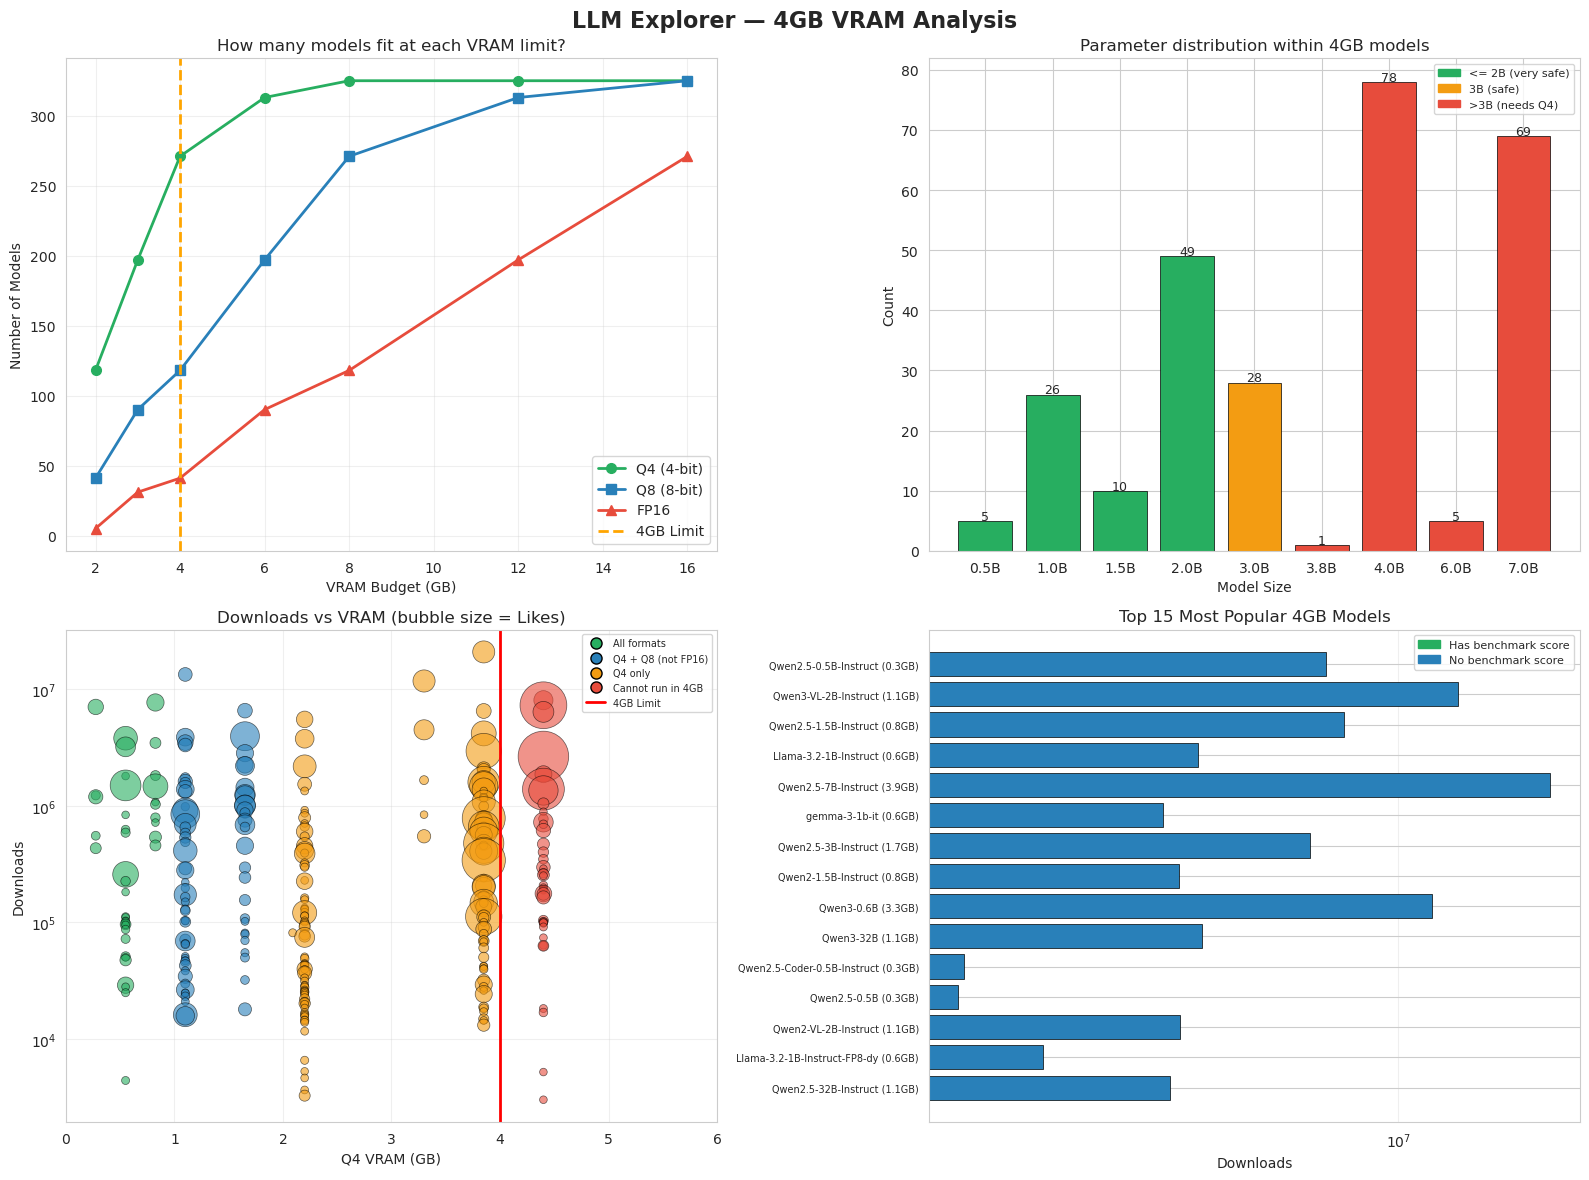

Charts complete


In [6]:
# ── Visualizations: 4GB VRAM Analysis ────────────────────────
# Four charts that summarize the model landscape from different angles.

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('LLM Explorer — 4GB VRAM Analysis', fontsize=16, fontweight='bold')

# ── Chart 1: Models available at each VRAM limit ─────────────
# Shows how the number of compatible models grows as budget increases.
# The orange line marks the 4GB threshold we focus on.
ax1 = axes[0, 0]
vram_limits = [2, 3, 4, 6, 8, 12, 16]
counts_q4   = [(df['VRAM_Q4_GB']   <= v).sum() for v in vram_limits]
counts_q8   = [(df['VRAM_Q8_GB']   <= v).sum() for v in vram_limits]
counts_fp16 = [(df['VRAM_FP16_GB'] <= v).sum() for v in vram_limits]
ax1.plot(vram_limits, counts_q4,   'o-', color='#27ae60', lw=2, ms=7, label='Q4 (4-bit)')
ax1.plot(vram_limits, counts_q8,   's-', color='#2980b9', lw=2, ms=7, label='Q8 (8-bit)')
ax1.plot(vram_limits, counts_fp16, '^-', color='#e74c3c', lw=2, ms=7, label='FP16')
ax1.axvline(x=4, color='orange', ls='--', lw=2, label='4GB Limit')
ax1.set_xlabel('VRAM Budget (GB)'); ax1.set_ylabel('Number of Models')
ax1.set_title('How many models fit at each VRAM limit?')
ax1.legend(); ax1.grid(alpha=0.3)

# ── Chart 2: Parameter distribution within 4GB ───────────────
# Shows how many models exist at each size class that fit in 4GB.
# Color indicates how comfortably they fit: green = very safe, red = tight.
ax2 = axes[0, 1]
param_counts = df_4gb['Params_B'].value_counts().sort_index()
colors = ['#27ae60' if p <= 2 else '#f39c12' if p <= 3 else '#e74c3c' for p in param_counts.index]
bars = ax2.bar([f'{p}B' for p in param_counts.index], param_counts.values,
               color=colors, edgecolor='black', lw=0.5)
for bar, val in zip(bars, param_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(val), ha='center', fontsize=9)
ax2.set_xlabel('Model Size'); ax2.set_ylabel('Count')
ax2.set_title('Parameter distribution within 4GB models')
ax2.legend(handles=[
    mpatches.Patch(color='#27ae60', label='<= 2B (very safe)'),
    mpatches.Patch(color='#f39c12', label='3B (safe)'),
    mpatches.Patch(color='#e74c3c', label='>3B (needs Q4)'),
], fontsize=8)

# ── Chart 3: Downloads vs VRAM scatter ───────────────────────
# Each bubble is one model. X = VRAM needed, Y = download count (log scale).
# Bubble size = Likes. Color = feasibility category.
# The red line marks the 4GB cutoff.
ax3 = axes[1, 0]
feasibility_colors = {
    'All formats':         '#27ae60',
    'Q4 + Q8 (not FP16)': '#2980b9',
    'Q4 only':             '#f39c12',
    'Cannot run in 4GB':   '#e74c3c',
}
for label, color in feasibility_colors.items():
    subset = df[df['4GB_Feasibility'] == label]
    if len(subset):
        ax3.scatter(subset['VRAM_Q4_GB'], subset['Downloads'],
                    s=subset['Likes']/5 + 30, c=color, alpha=0.6,
                    edgecolors='black', lw=0.5)
ax3.axvline(x=4, color='red', lw=2)
ax3.set_xlim(0, 6)
ax3.set_xlabel('Q4 VRAM (GB)'); ax3.set_ylabel('Downloads')
ax3.set_title('Downloads vs VRAM (bubble size = Likes)')
ax3.set_yscale('log'); ax3.grid(alpha=0.3)
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
           markeredgecolor='black', markersize=8, label=label)
    for label, color in feasibility_colors.items()
]
legend_elements.append(Line2D([0], [0], color='red', lw=2, label='4GB Limit'))
ax3.legend(handles=legend_elements, fontsize=7)

# ── Chart 4: Top 15 most popular 4GB models ──────────────────
# Horizontal bar chart sorted by downloads.
# Green = has a benchmark score, blue = not on the leaderboard.
ax4 = axes[1, 1]
top15       = df_4gb.head(15).copy()
short_names = [n.split('/')[-1][:28] for n in top15['Model Name']]
bar_colors  = ['#27ae60' if b > 0 else '#2980b9' for b in top15['Benchmark_Avg']]
ax4.barh(range(len(top15)), top15['Downloads'].values,
         color=bar_colors, edgecolor='black', lw=0.5)
ax4.set_yticks(range(len(top15)))
ax4.set_yticklabels([f'{n} ({v:.1f}GB)' for n, v in zip(short_names, top15['VRAM_Q4_GB'])], fontsize=7)
ax4.set_xlabel('Downloads'); ax4.set_title('Top 15 Most Popular 4GB Models')
ax4.invert_yaxis(); ax4.set_xscale('log'); ax4.grid(alpha=0.3, axis='x')
ax4.legend(handles=[
    mpatches.Patch(color='#27ae60', label='Has benchmark score'),
    mpatches.Patch(color='#2980b9', label='No benchmark score'),
], fontsize=8)

plt.tight_layout()
plt.show()
print('Charts complete')


## 🧭 Model Picker Wizard

> **Why:** With hundreds of models available, choosing the right one is overwhelming. This wizard narrows it down to 5 personalized recommendations based on your actual constraints.  
> **What:** Five questions about your hardware, use case, and priorities — the wizard filters and ranks models using the Efficiency score from Step 3

In [9]:
# Turn the LLM selection guide into a visual decision diagram
html = """
<style>
  .fw { font-family: sans-serif; max-width: 960px; margin: 0 auto; padding: 20px; }
  .fw h2 { text-align: center; font-size: 20px; margin-bottom: 24px; }
  .step-label {
    text-align: center; font-size: 11px; font-weight: bold; letter-spacing: 1.5px;
    text-transform: uppercase; color: #888; margin: 20px 0 6px;
  }
  .step-title {
    text-align: center; font-size: 15px; font-weight: bold;
    color: #2c3e50; margin-bottom: 14px;
  }
  .row { display: flex; justify-content: space-around; margin-bottom: 0; gap: 12px; }
  .col { display: flex; flex-direction: column; align-items: center; width: 22%; }
  .box {
    border-radius: 10px; padding: 10px 12px; text-align: center;
    font-size: 13px; width: 100%; box-sizing: border-box;
    border: 1.5px solid rgba(0,0,0,0.15);
    box-shadow: 0 1px 4px rgba(0,0,0,0.06);
  }
  .arrow { font-size: 20px; color: #bbb; margin: 4px 0; line-height: 1; }
  .divider { border: none; border-top: 1px dashed #ddd; margin: 20px 0; }
  .note {
    margin: 16px auto 6px; max-width: 700px; text-align: center;
    padding: 12px 20px; border-radius: 8px; font-size: 13px;
  }
  .note-yellow { background: #fff9e6; border: 1.5px solid #ffc107; }
  .note-red    { background: #fff0f0; border: 1.5px solid #f5c6cb; color: #888; font-size: 12px; }

  .t1 { background: #d5f5e3; border-color: #27ae60; }
  .t2 { background: #d6eaf8; border-color: #2980b9; }
  .t3 { background: #e8daef; border-color: #8e44ad; }
  .t4 { background: #fadbd8; border-color: #c0392b; }
  .u1 { background: #d1f2eb; border-color: #16a085; }
  .u2 { background: #fdebd0; border-color: #e67e22; }
  .u3 { background: #eaf4fb; border-color: #2980b9; }
  .u4 { background: #e8daef; border-color: #8e44ad; }
  .r  { background: #f0f0f0; border-color: #aaa; }
</style>

<div class="fw">
  <h2>🧭 How to Pick a 4GB LLM — Decision Framework</h2>
  <hr class="divider">

  <!-- STEP 1 -->
  <div class="step-label">Step 1</div>
  <div class="step-title">What is your VRAM budget?</div>
  <div class="row">
    <div class="col">
      <div class="box t1">< 2 GB<br><small style="color:#555">e.g. integrated GPU</small></div>
      <div class="arrow">↓</div>
      <div class="box t1"><b>TinyLlama 1.1B</b><br><small>Q4 ≈ 0.6 GB</small></div>
    </div>
    <div class="col">
      <div class="box t2">2–4 GB<br><small style="color:#555">entry GPU / M1 Mac</small></div>
      <div class="arrow">↓</div>
      <div class="box t2"><b>Phi-2 / Gemma-2B</b><br><small>Q4 ≈ 1–2 GB</small></div>
    </div>
    <div class="col">
      <div class="box t3">4–8 GB<br><small style="color:#555">mid-range GPU</small></div>
      <div class="arrow">↓</div>
      <div class="box t3"><b>Mistral 7B</b><br><small>Q4 ≈ 4 GB</small></div>
    </div>
    <div class="col">
      <div class="box t4">8 GB+<br><small style="color:#555">good GPU / M2+ Mac</small></div>
      <div class="arrow">↓</div>
      <div class="box t4"><b>Llama 3 8B</b><br><small>FP16 ≈ 16 GB</small></div>
    </div>
  </div>

  <hr class="divider">

  <!-- STEP 2 -->
  <div class="step-label">Step 2</div>
  <div class="step-title">What will you use it for?</div>
  <div class="row">
    <div class="col">
      <div class="box u1">📝 General Chat<br><small>Phi-2 Instruct</small></div>
    </div>
    <div class="col">
      <div class="box u2">💻 Code Generation<br><small>DeepSeek-Coder 1.3B</small></div>
    </div>
    <div class="col">
      <div class="box u3">🔢 Math & Reasoning<br><small>DeepSeek-Math 1.3B</small></div>
    </div>
    <div class="col">
      <div class="box u4">📊 Best Quality<br><small>Mistral 7B Instruct</small></div>
    </div>
  </div>

  <div class="row" style="margin:0">
    <div class="col"><div class="arrow">↓</div></div>
    <div class="col"><div class="arrow">↓</div></div>
    <div class="col"><div class="arrow">↓</div></div>
    <div class="col"><div class="arrow">↓</div></div>
  </div>

  <hr class="divider">

  <!-- STEP 3 -->
  <div class="step-label">Step 3</div>
  <div class="step-title">How to run it?</div>
  <div class="row">
    <div class="col">
      <div class="box r">🦙 <b>Ollama</b><br><small>Format: GGUF Q4<br>Simplest setup</small></div>
    </div>
    <div class="col">
      <div class="box r">⚙️ <b>llama.cpp</b><br><small>Format: GGUF Q4/Q8<br>Full control</small></div>
    </div>
    <div class="col">
      <div class="box r">🤗 <b>Transformers</b><br><small>Format: FP16 / Q8<br>Best quality</small></div>
    </div>
    <div class="col">
      <div class="box r">🚀 <b>vLLM</b><br><small>Format: FP16<br>High throughput</small></div>
    </div>
  </div>

  <hr class="divider">

  <!-- Notes -->
  <div class="note note-yellow">
    💡 <strong>Smart Rule:</strong> Even if you have 16 GB, use at most half for your model.
    Leave room for your OS, browser, and other apps. Running cool = running fast.
  </div>
  <div class="note note-red">
    ⚠️ All VRAM estimates include ~10% overhead for KV cache + runtime. Always leave headroom.
  </div>
</div>
"""

display(HTML(html))

## ✅ Data Sources & Methodology

| Field | Source |
|---|---|
| Model names & stats | HuggingFace API (`list_models`) |
| Parameter counts | Model card YAML, or parsed from model name |
| VRAM estimates | `Parameters × bytes_per_param × 1.10 overhead` |
| Downloads & Likes | Live HuggingFace community stats |
| Benchmark scores | Open LLM Leaderboard (`open-llm-leaderboard/contents`) |
| Efficiency score | `(Downloads + Likes×10) / (VRAM_Q4 + 0.1) × (1 + Recency/3650) × (1 + Benchmark/100)` |

> ⚠️ Parameter counts and VRAM estimates are approximate. Always verify before deploying.

---
## 🏆 How Benchmark Scores Work

Scores come from the [Open LLM Leaderboard](https://huggingface.co/spaces/open-llm-leaderboard/open_llm_leaderboard). Each model is evaluated on six standardized tests:

| Test | What It Measures |
|---|---|
| IFEval | Instruction-following accuracy |
| BBH (Big Bench Hard) | Complex multi-step reasoning |
| MATH Lvl 5 | High school competition math |
| GPQA | Graduate-level science questions |
| MUSR | Multi-step reasoning with long context |
| MMLU-PRO | Knowledge across 57 academic subjects |

`Average ⬆️` is the mean of these six scores. Typical ranges by model size:

| Score | Typical Size |
|---|---|
| 0–15 | Very small (0.5B–1B) |
| 15–25 | Small (1.5B–3B) |
| 25–40 | Medium (7B–9B) |
| 40+ | Large (34B+) |

> ⚠️ Only ~19% of models in our dataset have benchmark scores — many are never submitted to the leaderboard.

---
## 🆚 How We Compare to LLM Explorer

[LLM Explorer](https://llm-explorer.com/list/?4GB) is a curated directory of LLM models. Here is how our notebook differs:

| | LLM Explorer | This Notebook |
|---|---|---|
| Data source | Manually curated | HuggingFace API (live) |
| Model coverage | 50,000+ models | ~300 models (keyword search) |
| VRAM estimates | Human-verified | Formula-based |
| Ranking | Popularity + Recency + Expert judgment | Downloads + Likes + Recency + Benchmark |
| Benchmark data | MMLU / ARC / GSM8K and more | Open LLM Leaderboard (6 tests) |
| Filters | VRAM / format / license / context / MoE | VRAM / format / commercial use |
| Updates | Periodic manual updates | Every time you run the notebook |

**Key takeaway:** LLM Explorer is more comprehensive and human-verified. This notebook is more transparent — every number is reproducible and the data is always fresh.

---
## 🛠️ Tools to Run Models Locally

| Tool | Best For | Interface |
|---|---|---|
| [LM Studio](https://lmstudio.ai) | Beginners — easiest setup | GUI |
| [Ollama](https://ollama.com) | Simple CLI, great defaults | CLI |
| [llama.cpp](https://github.com/ggerganov/llama.cpp) | Full control, lightweight | CLI |
| [HuggingFace Transformers](https://huggingface.co/docs/transformers) | Research & fine-tuning | Python |
| [vLLM](https://github.com/vllm-project/vllm) | High-throughput serving | Python |
| [LLM Explorer](https://llm-explorer.com/list/?4GB) | Browse 4GB-compatible models | Web |

> 📌 LLM Explorer may occasionally be unavailable. You can always filter models directly on [HuggingFace](https://huggingface.co/models).


## 🤔 Reflection Questions

Think about what you observed while running this notebook. There are no single correct answers.

1. You have 4GB VRAM. Which model would you pick for a coding assistant, and why?
2. Why does Q4 quantization allow more models to fit — what are you trading off?
3. A model has 500,000 downloads but no benchmark score. Would you trust it? What would you check first?
4. You found two models with the same parameter count. One has a higher Efficiency score. Does that mean it's better for your use case?

---

<details>
<summary>💡 Click to see suggested directions (try answering first!)</summary>

**Q1.** Look at models tagged `Is_Code = True` in your Data Explorer results. Consider both VRAM fit and benchmark score — a smaller model that fits comfortably often runs faster and more reliably than one at the limit.

**Q2.** Q4 stores each parameter in 4 bits instead of 16 (FP16), cutting memory by ~75%. The trade-off is a small quality loss (~5–10%) because some numerical precision is lost during compression.

**Q3.** High downloads can mean popularity or automated pulls — not necessarily quality. First checks: Does it have a model card? Is the license clear? Is there a benchmark score or community evaluation?

**Q4.** Not necessarily. Efficiency score ranks models by popularity-per-GB, boosted by recency and benchmarks — it is useful for filtering, but it does not know your specific use case. A high-scoring general model may still underperform a specialized one for your task.

</details>